In [1]:
import numpy as np
import itertools
from collections import Counter
import os

# ---------- Configuration ----------
INPUT_FASTA = "pos_testing.fa"
OUTPUT_NPY = "pos_testing_3mer.npy"
K = 3 

def generate_kmers(k):
    """Generates all possible k-mer combinations of A, C, G, T."""
    bases = ['A', 'C', 'G', 'T']
    # Use itertools.product to get all 256 combinations for k=4
    return [''.join(p) for p in itertools.product(bases, repeat=k)]

def read_fasta(path):
    """Standard FASTA parser."""
    sequences = []
    with open(path, 'r') as f:
        seq = []
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if seq:
                    sequences.append("".join(seq))
                    seq = []
            else:
                seq.append(line.upper())
        if seq:
            sequences.append("".join(seq))
    return sequences

def get_kmer_embedding(sequence, k, kmer_to_idx):
    """
    Counts the frequency of each k-mer in a sequence.
    Returns a normalized frequency vector.
    """
    # Count all kmers in the sequence
    counts = Counter()
    # Sliding window to extract kmers
    for i in range(len(sequence) - k + 1):
        kmer = sequence[i:i+k]
        if kmer in kmer_to_idx: # Ignore kmers with 'N'
            counts[kmer] += 1
    
    # Create the vector
    vector = np.zeros(len(kmer_to_idx), dtype=np.float32)
    for kmer, count in counts.items():
        vector[kmer_to_idx[kmer]] = count
        
    # Normalization (Relative frequency)
    # This makes sequences of different lengths comparable
    total = np.sum(vector)
    if total > 0:
        vector /= total
        
    return vector

def main():
    if not os.path.exists(INPUT_FASTA):
        print(f"Error: {INPUT_FASTA} not found.")
        return

    # 1. Prepare k-mer mapping
    all_kmers = generate_kmers(K)
    kmer_to_idx = {kmer: i for i, kmer in enumerate(all_kmers)}
    print(f"Generated {len(all_kmers)} possible {K}-mers.")

    # 2. Load sequences
    sequences = read_fasta(INPUT_FASTA)
    print(f"Loaded {len(sequences)} sequences.")

    # 3. Process
    embeddings = []
    for i, seq in enumerate(sequences):
        emb = get_kmer_embedding(seq, K, kmer_to_idx)
        embeddings.append(emb)
        
        if i % 500 == 0 and i > 0:
            print(f"Processed {i}/{len(sequences)} sequences...")

    # 4. Save
    embeddings_array = np.vstack(embeddings)
    np.save(OUTPUT_NPY, embeddings_array)
    
    print("-" * 30)
    print(f"Success! Saved to {OUTPUT_NPY}")
    print(f"Final shape: {embeddings_array.shape}") # Expect (N, 256)

if __name__ == "__main__":
    main()

Generated 64 possible 3-mers.
Loaded 2889 sequences.
Processed 500/2889 sequences...
Processed 1000/2889 sequences...
Processed 1500/2889 sequences...
Processed 2000/2889 sequences...
Processed 2500/2889 sequences...
------------------------------
Success! Saved to pos_testing_3mer.npy
Final shape: (2889, 64)


In [2]:
import numpy as np
import itertools
from collections import Counter
import os

# ---------- Configuration ----------
INPUT_FASTA = "pos_training.fa"
OUTPUT_NPY = "pos_training_3mer.npy"
K = 3

def generate_kmers(k):
    """Generates all possible k-mer combinations of A, C, G, T."""
    bases = ['A', 'C', 'G', 'T']
    # Use itertools.product to get all 256 combinations for k=4
    return [''.join(p) for p in itertools.product(bases, repeat=k)]

def read_fasta(path):
    """Standard FASTA parser."""
    sequences = []
    with open(path, 'r') as f:
        seq = []
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if seq:
                    sequences.append("".join(seq))
                    seq = []
            else:
                seq.append(line.upper())
        if seq:
            sequences.append("".join(seq))
    return sequences

def get_kmer_embedding(sequence, k, kmer_to_idx):
    """
    Counts the frequency of each k-mer in a sequence.
    Returns a normalized frequency vector.
    """
    # Count all kmers in the sequence
    counts = Counter()
    # Sliding window to extract kmers
    for i in range(len(sequence) - k + 1):
        kmer = sequence[i:i+k]
        if kmer in kmer_to_idx: # Ignore kmers with 'N'
            counts[kmer] += 1
    
    # Create the vector
    vector = np.zeros(len(kmer_to_idx), dtype=np.float32)
    for kmer, count in counts.items():
        vector[kmer_to_idx[kmer]] = count
        
    # Normalization (Relative frequency)
    # This makes sequences of different lengths comparable
    total = np.sum(vector)
    if total > 0:
        vector /= total
        
    return vector

def main():
    if not os.path.exists(INPUT_FASTA):
        print(f"Error: {INPUT_FASTA} not found.")
        return

    # 1. Prepare k-mer mapping
    all_kmers = generate_kmers(K)
    kmer_to_idx = {kmer: i for i, kmer in enumerate(all_kmers)}
    print(f"Generated {len(all_kmers)} possible {K}-mers.")

    # 2. Load sequences
    sequences = read_fasta(INPUT_FASTA)
    print(f"Loaded {len(sequences)} sequences.")

    # 3. Process
    embeddings = []
    for i, seq in enumerate(sequences):
        emb = get_kmer_embedding(seq, K, kmer_to_idx)
        embeddings.append(emb)
        
        if i % 500 == 0 and i > 0:
            print(f"Processed {i}/{len(sequences)} sequences...")

    # 4. Save
    embeddings_array = np.vstack(embeddings)
    np.save(OUTPUT_NPY, embeddings_array)
    
    print("-" * 30)
    print(f"Success! Saved to {OUTPUT_NPY}")
    print(f"Final shape: {embeddings_array.shape}") # Expect (N, 256)

if __name__ == "__main__":
    main()

Generated 64 possible 3-mers.
Loaded 20178 sequences.
Processed 500/20178 sequences...
Processed 1000/20178 sequences...
Processed 1500/20178 sequences...
Processed 2000/20178 sequences...
Processed 2500/20178 sequences...
Processed 3000/20178 sequences...
Processed 3500/20178 sequences...
Processed 4000/20178 sequences...
Processed 4500/20178 sequences...
Processed 5000/20178 sequences...
Processed 5500/20178 sequences...
Processed 6000/20178 sequences...
Processed 6500/20178 sequences...
Processed 7000/20178 sequences...
Processed 7500/20178 sequences...
Processed 8000/20178 sequences...
Processed 8500/20178 sequences...
Processed 9000/20178 sequences...
Processed 9500/20178 sequences...
Processed 10000/20178 sequences...
Processed 10500/20178 sequences...
Processed 11000/20178 sequences...
Processed 11500/20178 sequences...
Processed 12000/20178 sequences...
Processed 12500/20178 sequences...
Processed 13000/20178 sequences...
Processed 13500/20178 sequences...
Processed 14000/20178

In [3]:
import numpy as np
import itertools
from collections import Counter
import os

# ---------- Configuration ----------
INPUT_FASTA = "neg_training.fa"
OUTPUT_NPY = "neg_training_3mer.npy"
K = 3

def generate_kmers(k):
    """Generates all possible k-mer combinations of A, C, G, T."""
    bases = ['A', 'C', 'G', 'T']
    # Use itertools.product to get all 256 combinations for k=4
    return [''.join(p) for p in itertools.product(bases, repeat=k)]

def read_fasta(path):
    """Standard FASTA parser."""
    sequences = []
    with open(path, 'r') as f:
        seq = []
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if seq:
                    sequences.append("".join(seq))
                    seq = []
            else:
                seq.append(line.upper())
        if seq:
            sequences.append("".join(seq))
    return sequences

def get_kmer_embedding(sequence, k, kmer_to_idx):
    """
    Counts the frequency of each k-mer in a sequence.
    Returns a normalized frequency vector.
    """
    # Count all kmers in the sequence
    counts = Counter()
    # Sliding window to extract kmers
    for i in range(len(sequence) - k + 1):
        kmer = sequence[i:i+k]
        if kmer in kmer_to_idx: # Ignore kmers with 'N'
            counts[kmer] += 1
    
    # Create the vector
    vector = np.zeros(len(kmer_to_idx), dtype=np.float32)
    for kmer, count in counts.items():
        vector[kmer_to_idx[kmer]] = count
        
    # Normalization (Relative frequency)
    # This makes sequences of different lengths comparable
    total = np.sum(vector)
    if total > 0:
        vector /= total
        
    return vector

def main():
    if not os.path.exists(INPUT_FASTA):
        print(f"Error: {INPUT_FASTA} not found.")
        return

    # 1. Prepare k-mer mapping
    all_kmers = generate_kmers(K)
    kmer_to_idx = {kmer: i for i, kmer in enumerate(all_kmers)}
    print(f"Generated {len(all_kmers)} possible {K}-mers.")

    # 2. Load sequences
    sequences = read_fasta(INPUT_FASTA)
    print(f"Loaded {len(sequences)} sequences.")

    # 3. Process
    embeddings = []
    for i, seq in enumerate(sequences):
        emb = get_kmer_embedding(seq, K, kmer_to_idx)
        embeddings.append(emb)
        
        if i % 500 == 0 and i > 0:
            print(f"Processed {i}/{len(sequences)} sequences...")

    # 4. Save
    embeddings_array = np.vstack(embeddings)
    np.save(OUTPUT_NPY, embeddings_array)
    
    print("-" * 30)
    print(f"Success! Saved to {OUTPUT_NPY}")
    print(f"Final shape: {embeddings_array.shape}") # Expect (N, 256)

if __name__ == "__main__":
    main()

Generated 64 possible 3-mers.
Loaded 20178 sequences.
Processed 500/20178 sequences...
Processed 1000/20178 sequences...
Processed 1500/20178 sequences...
Processed 2000/20178 sequences...
Processed 2500/20178 sequences...
Processed 3000/20178 sequences...
Processed 3500/20178 sequences...
Processed 4000/20178 sequences...
Processed 4500/20178 sequences...
Processed 5000/20178 sequences...
Processed 5500/20178 sequences...
Processed 6000/20178 sequences...
Processed 6500/20178 sequences...
Processed 7000/20178 sequences...
Processed 7500/20178 sequences...
Processed 8000/20178 sequences...
Processed 8500/20178 sequences...
Processed 9000/20178 sequences...
Processed 9500/20178 sequences...
Processed 10000/20178 sequences...
Processed 10500/20178 sequences...
Processed 11000/20178 sequences...
Processed 11500/20178 sequences...
Processed 12000/20178 sequences...
Processed 12500/20178 sequences...
Processed 13000/20178 sequences...
Processed 13500/20178 sequences...
Processed 14000/20178

In [4]:
import numpy as np
import itertools
from collections import Counter
import os

# ---------- Configuration ----------
INPUT_FASTA = "pos_evaluation.fa"
OUTPUT_NPY = "pos_evaluation_3mer.npy"
K = 3

def generate_kmers(k):
    """Generates all possible k-mer combinations of A, C, G, T."""
    bases = ['A', 'C', 'G', 'T']
    # Use itertools.product to get all 256 combinations for k=4
    return [''.join(p) for p in itertools.product(bases, repeat=k)]

def read_fasta(path):
    """Standard FASTA parser."""
    sequences = []
    with open(path, 'r') as f:
        seq = []
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if seq:
                    sequences.append("".join(seq))
                    seq = []
            else:
                seq.append(line.upper())
        if seq:
            sequences.append("".join(seq))
    return sequences

def get_kmer_embedding(sequence, k, kmer_to_idx):
    """
    Counts the frequency of each k-mer in a sequence.
    Returns a normalized frequency vector.
    """
    # Count all kmers in the sequence
    counts = Counter()
    # Sliding window to extract kmers
    for i in range(len(sequence) - k + 1):
        kmer = sequence[i:i+k]
        if kmer in kmer_to_idx: # Ignore kmers with 'N'
            counts[kmer] += 1
    
    # Create the vector
    vector = np.zeros(len(kmer_to_idx), dtype=np.float32)
    for kmer, count in counts.items():
        vector[kmer_to_idx[kmer]] = count
        
    # Normalization (Relative frequency)
    # This makes sequences of different lengths comparable
    total = np.sum(vector)
    if total > 0:
        vector /= total
        
    return vector

def main():
    if not os.path.exists(INPUT_FASTA):
        print(f"Error: {INPUT_FASTA} not found.")
        return

    # 1. Prepare k-mer mapping
    all_kmers = generate_kmers(K)
    kmer_to_idx = {kmer: i for i, kmer in enumerate(all_kmers)}
    print(f"Generated {len(all_kmers)} possible {K}-mers.")

    # 2. Load sequences
    sequences = read_fasta(INPUT_FASTA)
    print(f"Loaded {len(sequences)} sequences.")

    # 3. Process
    embeddings = []
    for i, seq in enumerate(sequences):
        emb = get_kmer_embedding(seq, K, kmer_to_idx)
        embeddings.append(emb)
        
        if i % 500 == 0 and i > 0:
            print(f"Processed {i}/{len(sequences)} sequences...")

    # 4. Save
    embeddings_array = np.vstack(embeddings)
    np.save(OUTPUT_NPY, embeddings_array)
    
    print("-" * 30)
    print(f"Success! Saved to {OUTPUT_NPY}")
    print(f"Final shape: {embeddings_array.shape}") # Expect (N, 256)

if __name__ == "__main__":
    main()

Generated 64 possible 3-mers.
Loaded 5769 sequences.
Processed 500/5769 sequences...
Processed 1000/5769 sequences...
Processed 1500/5769 sequences...
Processed 2000/5769 sequences...
Processed 2500/5769 sequences...
Processed 3000/5769 sequences...
Processed 3500/5769 sequences...
Processed 4000/5769 sequences...
Processed 4500/5769 sequences...
Processed 5000/5769 sequences...
Processed 5500/5769 sequences...
------------------------------
Success! Saved to pos_evaluation_3mer.npy
Final shape: (5769, 64)


In [5]:
import numpy as np
import itertools
from collections import Counter
import os

# ---------- Configuration ----------
INPUT_FASTA = "neg_evaluation.fa"
OUTPUT_NPY = "neg_evaluation_3mer.npy"
K = 3

def generate_kmers(k):
    """Generates all possible k-mer combinations of A, C, G, T."""
    bases = ['A', 'C', 'G', 'T']
    # Use itertools.product to get all 256 combinations for k=4
    return [''.join(p) for p in itertools.product(bases, repeat=k)]

def read_fasta(path):
    """Standard FASTA parser."""
    sequences = []
    with open(path, 'r') as f:
        seq = []
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if seq:
                    sequences.append("".join(seq))
                    seq = []
            else:
                seq.append(line.upper())
        if seq:
            sequences.append("".join(seq))
    return sequences

def get_kmer_embedding(sequence, k, kmer_to_idx):
    """
    Counts the frequency of each k-mer in a sequence.
    Returns a normalized frequency vector.
    """
    # Count all kmers in the sequence
    counts = Counter()
    # Sliding window to extract kmers
    for i in range(len(sequence) - k + 1):
        kmer = sequence[i:i+k]
        if kmer in kmer_to_idx: # Ignore kmers with 'N'
            counts[kmer] += 1
    
    # Create the vector
    vector = np.zeros(len(kmer_to_idx), dtype=np.float32)
    for kmer, count in counts.items():
        vector[kmer_to_idx[kmer]] = count
        
    # Normalization (Relative frequency)
    # This makes sequences of different lengths comparable
    total = np.sum(vector)
    if total > 0:
        vector /= total
        
    return vector

def main():
    if not os.path.exists(INPUT_FASTA):
        print(f"Error: {INPUT_FASTA} not found.")
        return

    # 1. Prepare k-mer mapping
    all_kmers = generate_kmers(K)
    kmer_to_idx = {kmer: i for i, kmer in enumerate(all_kmers)}
    print(f"Generated {len(all_kmers)} possible {K}-mers.")

    # 2. Load sequences
    sequences = read_fasta(INPUT_FASTA)
    print(f"Loaded {len(sequences)} sequences.")

    # 3. Process
    embeddings = []
    for i, seq in enumerate(sequences):
        emb = get_kmer_embedding(seq, K, kmer_to_idx)
        embeddings.append(emb)
        
        if i % 500 == 0 and i > 0:
            print(f"Processed {i}/{len(sequences)} sequences...")

    # 4. Save
    embeddings_array = np.vstack(embeddings)
    np.save(OUTPUT_NPY, embeddings_array)
    
    print("-" * 30)
    print(f"Success! Saved to {OUTPUT_NPY}")
    print(f"Final shape: {embeddings_array.shape}") # Expect (N, 256)

if __name__ == "__main__":
    main()

Generated 64 possible 3-mers.
Loaded 5769 sequences.
Processed 500/5769 sequences...
Processed 1000/5769 sequences...
Processed 1500/5769 sequences...
Processed 2000/5769 sequences...
Processed 2500/5769 sequences...
Processed 3000/5769 sequences...
Processed 3500/5769 sequences...
Processed 4000/5769 sequences...
Processed 4500/5769 sequences...
Processed 5000/5769 sequences...
Processed 5500/5769 sequences...
------------------------------
Success! Saved to neg_evaluation_3mer.npy
Final shape: (5769, 64)


In [6]:
import numpy as np
import itertools
from collections import Counter
import os

# ---------- Configuration ----------
INPUT_FASTA = "neg_testing.fa"
OUTPUT_NPY = "neg_testing_3mer.npy"
K = 3

def generate_kmers(k):
    """Generates all possible k-mer combinations of A, C, G, T."""
    bases = ['A', 'C', 'G', 'T']
    # Use itertools.product to get all 256 combinations for k=4
    return [''.join(p) for p in itertools.product(bases, repeat=k)]

def read_fasta(path):
    """Standard FASTA parser."""
    sequences = []
    with open(path, 'r') as f:
        seq = []
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if seq:
                    sequences.append("".join(seq))
                    seq = []
            else:
                seq.append(line.upper())
        if seq:
            sequences.append("".join(seq))
    return sequences

def get_kmer_embedding(sequence, k, kmer_to_idx):
    """
    Counts the frequency of each k-mer in a sequence.
    Returns a normalized frequency vector.
    """
    # Count all kmers in the sequence
    counts = Counter()
    # Sliding window to extract kmers
    for i in range(len(sequence) - k + 1):
        kmer = sequence[i:i+k]
        if kmer in kmer_to_idx: # Ignore kmers with 'N'
            counts[kmer] += 1
    
    # Create the vector
    vector = np.zeros(len(kmer_to_idx), dtype=np.float32)
    for kmer, count in counts.items():
        vector[kmer_to_idx[kmer]] = count
        
    # Normalization (Relative frequency)
    # This makes sequences of different lengths comparable
    total = np.sum(vector)
    if total > 0:
        vector /= total
        
    return vector

def main():
    if not os.path.exists(INPUT_FASTA):
        print(f"Error: {INPUT_FASTA} not found.")
        return

    # 1. Prepare k-mer mapping
    all_kmers = generate_kmers(K)
    kmer_to_idx = {kmer: i for i, kmer in enumerate(all_kmers)}
    print(f"Generated {len(all_kmers)} possible {K}-mers.")

    # 2. Load sequences
    sequences = read_fasta(INPUT_FASTA)
    print(f"Loaded {len(sequences)} sequences.")

    # 3. Process
    embeddings = []
    for i, seq in enumerate(sequences):
        emb = get_kmer_embedding(seq, K, kmer_to_idx)
        embeddings.append(emb)
        
        if i % 500 == 0 and i > 0:
            print(f"Processed {i}/{len(sequences)} sequences...")

    # 4. Save
    embeddings_array = np.vstack(embeddings)
    np.save(OUTPUT_NPY, embeddings_array)
    
    print("-" * 30)
    print(f"Success! Saved to {OUTPUT_NPY}")
    print(f"Final shape: {embeddings_array.shape}") # Expect (N, 256)

if __name__ == "__main__":
    main()

Generated 64 possible 3-mers.
Loaded 2889 sequences.
Processed 500/2889 sequences...
Processed 1000/2889 sequences...
Processed 1500/2889 sequences...
Processed 2000/2889 sequences...
Processed 2500/2889 sequences...
------------------------------
Success! Saved to neg_testing_3mer.npy
Final shape: (2889, 64)


/data/yafan/software/miniconda3/envs/rloop_bench/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/data/yafan/software/miniconda3/envs/rloop_bench/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Plot saved to 3mer_umap_visualization_cosine.pdf


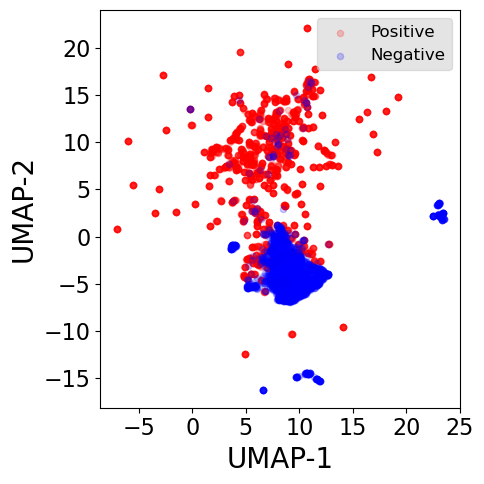

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Try importing UMAP
try:
    import umap
except ImportError:
    raise ImportError("umap-learn is not installed in this environment. Please install it first.")

# Set matplotlib parameters
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['font.size'] = 12

# Load embeddings
pos = np.load("pos_testing_3mer.npy")
neg = np.load("neg_testing_3mer.npy")

# Combine data
X = np.vstack([pos, neg])
labels = np.array([1]*len(pos) + [0]*len(neg))

# Run UMAP
reducer = umap.UMAP(
    metric='cosine', 
    random_state=423
)
X_umap = reducer.fit_transform(X)
X_umap = reducer.fit_transform(X)


# Plot - 5x5 square figure
plt.figure(figsize=(5, 5))

# Scatter plot
plt.scatter(X_umap[labels == 1, 0], X_umap[labels == 1, 1], 
            c='red', alpha=0.2, label='Positive', s=20)
plt.scatter(X_umap[labels == 0, 0], X_umap[labels == 0, 1], 
            c='blue', alpha=0.2, label='Negative', s=20)

# Legend with grey frame
legend = plt.legend(frameon=True, fontsize=12)
legend.get_frame().set_facecolor('lightgrey')
legend.get_frame().set_alpha(0.6)

# Axis labels with size 20
plt.xlabel("UMAP-1", fontsize=20)
plt.ylabel("UMAP-2", fontsize=20)

# Tick labels size 16
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Remove title
# plt.title("...")  # commented out

# Adjust layout
plt.tight_layout()

# Save as PDF
save_path = "3mer_umap_visualization_cosine.pdf"
plt.savefig(save_path, format='pdf', bbox_inches='tight')
print(f"Plot saved to {save_path}")

# Show plot
plt.show()